# Implementação didática

## 1. Introdução

O objetivo desse notebook é fazer uma implementação didática de Autoencoders utilizando PyTorch e o conjunto de dados MNIST [2]. O código recebe esse conjunto de dados (cada exemplo tem 784 pixels, sendo cada pixel uma feature) e insere eles em uma rede neural autoencoder com _bottleneck_ de 3 neurônios, e depois tenta reconstruir os dados originais. Esse código é uma versão modificada e explicada do código do tutorial da referência [1]. 

## 2. Importações de bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 3. Importando o Dataset

O código abaixo importa o dataset já transformando os exemplos em tensores, em seguida, convertendo o dataset em um DataLoader, uma estrutura de dados do PyTorch que já separa os dados em _batchs_ para o treino, o que é útil pois explora a paralelização. 

In [2]:
TRANSFORM = transforms.ToTensor()

mnist_data = datasets.MNIST(root = './data', train = True, download = True, transform = TRANSFORM)

data_loader = torch.utils.data.DataLoader(dataset = mnist_data, 
                                          batch_size = 64,
                                          shuffle = True)

O código abaixo busca entender quais são os valores máximos e mínimos das features nos exemplos do dataset. Isso é importante, pois a última função de ativação do decoder precisa ajustar os dados para o conjunto imagem correto. 

In [3]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


## 4. A estrutura do Autoencoder

Aqui definimos a estrutura do autoencoder, de forma semelhante em [3] para uma MLP. 

A camada inicial do encoder deve ter tantos neurônios quanto o número de features, e o número de neurônios deve ser reduzido de forma gradual até o _bottleneck_ (gargalo em português). No caso, o bottleneck definido foi de 3 neurônios. Então, o encoder recebeu uma informação de 784 "valores" e comprimiu ela para apenas 3 "valores". A função de ativação ReLU foi utilizada para colocar não-linearidade no modelo. 

Em relação ao decoder, como dito anteriormente, sua estrutura é a inversa do encoder, com exceção da função sigmoidal adicionada na última camada, que é responsável por recolocar a informação que passa pela rede no intervalo [0,1]. 

O `foward` determina como os dados passam pela rede. No caso, ela retorna apenas o decoder, pois seu resultado (a reconstrução feita pela rede) que iremos comparar com a imagem inicial. Retornar o encoder pode ter aplicações interessantes, como tem no caso do notebook `Autoencoders_PCA_estudo.ipynb`. 

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(), 
            nn.Linear(128, 64), 
            nn.ReLU(), 
            nn.Linear(64, 12), 
            nn.ReLU(), 
            nn.Linear(12, 3) 
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(), 
            nn.Linear(12, 64), 
            nn.ReLU(), 
            nn.Linear(64, 128), 
            nn.ReLU(), 
            nn.Linear(128, 28*28), 
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


Aqui temos algumas configurações para o modelo. Primeiro, fazemos a instância. Depois, definimos o critério que será utilizado para orientar o treino, no caso, o MSE. Definimos também o otimizador, no caso o `Adam`, com a taxa de aprendizagem e adicionamos o regularizador `weight_decay`, que é indicado para reduzir overfitting, e funciona "puxando" os valores dos pesos pra baixo. 

In [5]:
model = Autoencoder() # instância do modelo
criterion = nn.MSELoss() 
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-5) # configuração do otimizador

## 5. Loop de treino da rede

Determinamos então o loop de treino. A ideia é muito semelhante ao treino da MLP. OS detalhes estão nos comentários do código. 

In [9]:
fixed_imgs, _ = next(iter(data_loader))
fixed_imgs = fixed_imgs.reshape(-1, 28*28)

# Essa parte do código fixa as imagens que serão impressas na tela posteriormente, 
# para melhor visualização do desempenho da rede. 

num_epochs = 10
outputs = []

for epoch in range(num_epochs):

    for (img, _) in data_loader:

        img = img.reshape(-1, 28*28) # faz o reshape da imagem, para que ela possa ser processada pelo autoencoder

        recon = model(img) # recebe o retorno do decoder

        loss = criterion(recon, img) # calcula a loss com base na imagem original

        optimizer.zero_grad() # zera os gradientes
        loss.backward() # calcula o backpropagation [4]
        optimizer.step() # atualiza os pesos

    # with torch.no_grad():
    #     fixed_recon = model(fixed_imgs) # faz a reconstrução das imagens fora do treino, não queremos aqui

    outputs.append((epoch, fixed_imgs, fixed_recon))

    print(f'Epoch:{epoch+1}, Loss:{loss.item():.4f}')

Epoch:1, Loss:0.0266
Epoch:2, Loss:0.0364
Epoch:3, Loss:0.0339
Epoch:4, Loss:0.0367
Epoch:5, Loss:0.0326
Epoch:6, Loss:0.0362
Epoch:7, Loss:0.0338
Epoch:8, Loss:0.0304
Epoch:9, Loss:0.0286
Epoch:10, Loss:0.0316


## 6. Visualização dos resultados

O código abaixo serve para plotar a imagem original em cima, e embaixo a reconstrução, ao longo de algumas das épocas do treino. 

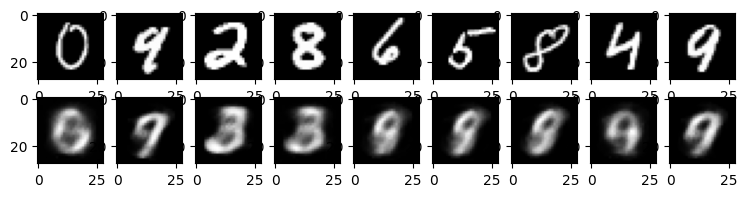

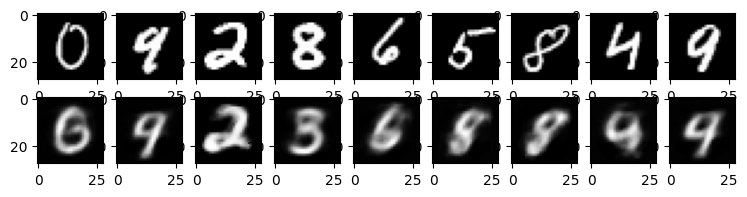

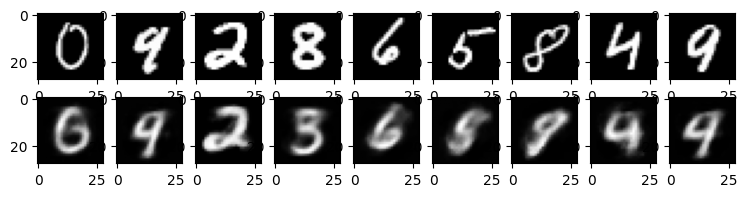

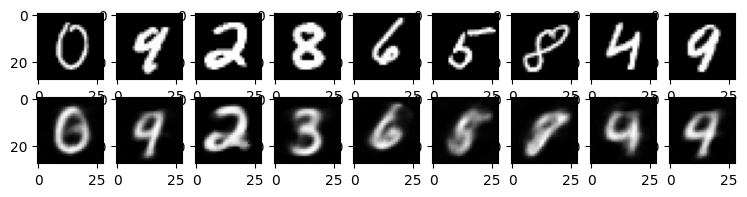

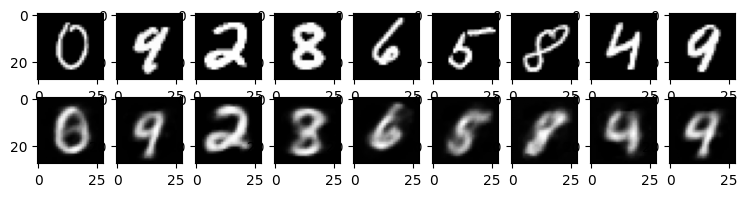

In [8]:
for k in range(0, num_epochs, 2):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        item = item.reshape(-1, 28,28) 
        # item: 1, 28, 28
        plt.imshow(item[0])
            
    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1) 
        item = item.reshape(-1, 28,28) 
        # item: 1, 28, 28
        plt.imshow(item[0])

Bem interessante o que o autoencoder consegue fazer com apenas 3 neurônios no _bottleneck_ e apenas 10 épocas. Podemos ver que apesar de as imagens estarem um pouco borradas, os números são reconhecíveis. Podemos ver também como o modelo melhora durante o treinamento. 

## 7. Referências

[1] PyTorch. MNIST Dataset. Disponível em: <https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html>. Acesso em 10 mai. 2026. 

[2] LOEBER, Patrick. Autoencoder In PyTorch - Theory & Implementation. YouTube, 22 mar. 2021. Disponível em: https://www.youtube.com/watch?v=zp8clK9yCro
. Acesso em: 9 maio 2026.

[3] CASSAR, Daniel. ATP-303 NN 3.2 - Construindo e treinando redes neurais com PyTorch e Lightning.ipynb. 2026. Material didático disponibilizado no Teams do curso de Redes Neurais e Algoritmos Genéticos da Ilum Escola de Ciência, Campinas. Acesso em 10 mai. 2026. 

[4] OPENAI. ChatGPT. 2026. Disponível em: https://chat.openai.com/. Acesso em: 10 mai. 2026.   
